In [11]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [12]:
import csv
import numpy as np
import cv2
import torch
import torch.nn as nn
import timm
import mediapipe as mp
from pathlib import Path
from PIL import Image, ImageEnhance
from torchvision import transforms

# ---- video pipeline: change VIDEO_NAME to run the whole notebook on another picklist ----
VIDEO_DIR = Path("../hmm-testing/picklist_videos")
VIDEO_NAME = "picklist_051.MP4"

VIDEO_PATH = VIDEO_DIR / VIDEO_NAME

# ---- output paths (CSVs in subfolder to keep objectdetector/ tidy) ----
CSV_OUTPUT_DIR = Path("csv_outputs")
CSV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HTK_FEATURES_DIR = Path("../hmm-testing/processed_features_3d")
HTK_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_holding_timeseries.csv"

# ---- paths ----
HEAD_CKPT = "holding_head.pt"          # the checkpoint you trained

# ---- must match how you TRAINED (these settings affect the saved head) ----
DINO_NAME   = "dinov2_vits14"
EMB_DIM     = 384
HIDDEN      = 0                         # 0 = linear probe; set to what you trained with
PAD         = 0.4                       # box expansion; must equal training PAD
HOLDING_IDX = 1

# ---- inference knobs ----
CONTRAST            = 1.5
RIGHT_ON_RIGHT_SIDE = True             # target right hand sits on RIGHT of frame (mirrored view)
SMOOTH_WIN          = 1                 # median smoothing window (odd); 1 = off
FRAME_STRIDE        = 5                 # score every Nth frame (raise to speed up)

DIRECTION_CSV    = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_hand_direction.csv"
ARUCO_CSV        = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_aruco_net_timeseries.csv"
STATE_CSV        = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_state_timeseries.csv"
COMBINED_VIDEO   = f"{VIDEO_PATH.stem}_combined_annotated.mp4"
HOLDING_SMOOTHED_CSV   = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_holding_timeseries_smoothed.csv"
DIRECTION_SMOOTHED_CSV = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_hand_direction_smoothed.csv"
ARUCO_SMOOTHED_CSV     = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_aruco_net_timeseries_smoothed.csv"
STATE_SMOOTHED_CSV     = CSV_OUTPUT_DIR / f"{VIDEO_PATH.stem}_state_timeseries_smoothed.csv"

HOLD_THRESHOLD      = 0.15   # CARRY if P(hold) > this (when dir > DIRECTION_THRESHOLD)
DIRECTION_THRESHOLD = 0.6    # CARRY/EMPTY when dir > 0.5; PICK/PLACE when dir <= 0.5
PLOT_SMOOTH_WIN     = 5      # median window for visualization / smoothed CSV export

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("video:", VIDEO_PATH)
print("csv dir:", CSV_OUTPUT_DIR)
print("csv:", OUTPUT_CSV)
print("direction:", DIRECTION_CSV)
print("aruco:", ARUCO_CSV)
print("state:", STATE_CSV)
print("state (smoothed):", STATE_SMOOTHED_CSV)
print("annotated:", COMBINED_VIDEO)

device: cpu
video: ../hmm-testing/picklist_videos/picklist_051.MP4
csv dir: csv_outputs
csv: csv_outputs/picklist_051_holding_timeseries.csv
direction: csv_outputs/picklist_051_hand_direction.csv
aruco: csv_outputs/picklist_051_aruco_net_timeseries.csv
state: csv_outputs/picklist_051_state_timeseries.csv
state (smoothed): csv_outputs/picklist_051_state_timeseries_smoothed.csv
annotated: picklist_051_combined_annotated.mp4


In [13]:
# ---- frozen DINOv2 backbone (timm — Python 3.9 compatible) ----
_DINO_TIMM = {
    "dinov2_vits14": "vit_small_patch14_dinov2.lvd142m",
    "dinov2_vitb14": "vit_base_patch14_dinov2.lvd142m",
    "dinov2_vitl14": "vit_large_patch14_dinov2.lvd142m",
    "dinov2_vitg14": "vit_giant_patch14_dinov2.lvd142m",
}
dino = timm.create_model(_DINO_TIMM[DINO_NAME], pretrained=True, num_classes=0).to(device).eval()
for p in dino.parameters():
    p.requires_grad_(False)

tf = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ---- trained head ----
def make_head():
    if HIDDEN > 0:
        return nn.Sequential(nn.Linear(EMB_DIM, HIDDEN), nn.ReLU(),
                             nn.Dropout(0.3), nn.Linear(HIDDEN, 2))
    return nn.Linear(EMB_DIM, 2)

head = make_head().to(device)
head.load_state_dict(torch.load(HEAD_CKPT, map_location=device, weights_only=False))
head.eval()

# ---- hand detector (Solutions API — shared by holding + direction) ----
mp_hands = mp.solutions.hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

_HAND_BONES = [(0, 5), (5, 17)]

def expand_and_crop(img_rgb, box, pad=PAD):
    H, W = img_rgb.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    x1 -= pad * bw; x2 += pad * bw; y1 -= pad * bh; y2 += pad * bh
    x1, y1 = max(0, int(round(x1))), max(0, int(round(y1)))
    x2, y2 = min(W, int(round(x2))), min(H, int(round(y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    return Image.fromarray(img_rgb[y1:y2, x1:x2])

@torch.no_grad()
def embed(pil_list):
    x = torch.stack([tf(im) for im in pil_list]).to(device)
    return dino(x).cpu()

def select_right_hand_idx(res):
    """Index of the right hand in MediaPipe result, or None."""
    if not res.multi_hand_landmarks:
        return None
    hands = res.multi_hand_landmarks
    wrist_x = lambda i: hands[i].landmark[0].x
    if len(hands) >= 2:
        return (max if RIGHT_ON_RIGHT_SIDE else min)(range(len(hands)), key=wrist_x)
    label = res.multi_handedness[0].classification[0].label
    wrong = (label == "Left"  and wrist_x(0) <= 0.5) if RIGHT_ON_RIGHT_SIDE \
       else (label == "Right" and wrist_x(0) >= 0.5)
    return None if wrong else 0

def palm_normal(world_xyz):
    vecs = np.array([world_xyz[e] - world_xyz[s] for s, e in _HAND_BONES])
    return np.cross(vecs[0], vecs[1])

def palm_normal_z(res, idx):
    """Z component of unit palm normal (-1=facing camera, +1=away)."""
    world = np.array([[lm.x, lm.y, lm.z] for lm in res.multi_hand_world_landmarks[idx].landmark])
    label = res.multi_handedness[idx].classification[0].label
    if label == "Left":
        world[:, 0] *= -1
    vec = palm_normal(world)
    return float(vec[2] / np.linalg.norm(vec))

@torch.no_grad()
def analyze_frame(img_bgr):
    """One MediaPipe pass -> (P(holding), palm_dir_z). No hand -> (-1.0, -1.0)."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    res = mp_hands.process(rgb)
    idx = select_right_hand_idx(res)
    if idx is None:
        return -1.0, -1.0

    direction_z = palm_normal_z(res, idx)

    landmarks = res.multi_hand_landmarks[idx].landmark
    H, W = rgb.shape[:2]
    xs = [lm.x * W for lm in landmarks]
    ys = [lm.y * H for lm in landmarks]
    crop = expand_and_crop(rgb, (min(xs), min(ys), max(xs), max(ys)), pad=PAD)
    if crop is None:
        return 0.0, direction_z
    if CONTRAST != 1.0:
        crop = ImageEnhance.Contrast(crop).enhance(CONTRAST)
    hold_prob = float(head(embed([crop]).to(device)).softmax(1)[0, HOLDING_IDX])
    return hold_prob, direction_z

I0000 00:00:1782538945.898741       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


In [14]:
# ---- ArUco detector (grid125 net feature; shared by single-video + batch) ----
ORIGINAL_FRAME_WIDTH = 1920
ORIGINAL_FRAME_HEIGHT = 1080
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_1000)
ARUCO_DETECTOR = cv2.aruco.ArucoDetector(ARUCO_DICT)

PICK_MARKER_IDS = frozenset(range(120))
PLACE_MARKER_IDS = frozenset({990, 991, 992, 993, 994})
GRID125_MARKER_IDS = PICK_MARKER_IDS | PLACE_MARKER_IDS


def preprocess_aruco_frame_bgr(frame_bgr):
    """Resize + RGB, matching extract_features.py / aruco_net_value_inference.ipynb."""
    resized = cv2.resize(frame_bgr, (ORIGINAL_FRAME_WIDTH, ORIGINAL_FRAME_HEIGHT))
    return cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)


def aruco_marker_value(marker_id: int) -> int:
    """Grid125 convention: 0-119 pick (+1), 990-994 place (-1)."""
    if marker_id in PICK_MARKER_IDS:
        return 1
    if marker_id in PLACE_MARKER_IDS:
        return -1
    return 0


def detect_grid125_markers(frame_bgr):
    """
    Detect grid125 ArUco markers on one frame.
    Returns dicts with id, original-frame corners, and center for optional annotation.
    """
    rgb = preprocess_aruco_frame_bgr(frame_bgr)
    corners, ids, _ = ARUCO_DETECTOR.detectMarkers(rgb)
    if ids is None or len(ids) == 0:
        return []

    h_orig, w_orig = frame_bgr.shape[:2]
    sx = w_orig / ORIGINAL_FRAME_WIDTH
    sy = h_orig / ORIGINAL_FRAME_HEIGHT

    detections = []
    for i, marker_id in enumerate(ids.flatten().astype(int)):
        if marker_id not in GRID125_MARKER_IDS:
            continue
        pts = corners[i][0].astype(np.float32)
        pts_orig = pts.copy()
        pts_orig[:, 0] *= sx
        pts_orig[:, 1] *= sy
        detections.append(
            {
                "id": marker_id,
                "corners": pts_orig,
                "center": (float(np.mean(pts_orig[:, 0])), float(np.mean(pts_orig[:, 1]))),
            }
        )
    return detections


def score_aruco_detections(detections):
    """Deduplicate marker IDs and compute net pick/place score."""
    unique_ids = sorted({d["id"] for d in detections})
    pick_count = sum(1 for mid in unique_ids if mid in PICK_MARKER_IDS)
    place_count = sum(1 for mid in unique_ids if mid in PLACE_MARKER_IDS)
    net_aruco = sum(aruco_marker_value(mid) for mid in unique_ids)
    return net_aruco, pick_count, place_count, unique_ids


def analyze_aruco_frame(frame_bgr):
    """One frame -> (net_aruco, pick_count, place_count, unique_ids, detections)."""
    detections = detect_grid125_markers(frame_bgr)
    net_aruco, pick_count, place_count, unique_ids = score_aruco_detections(detections)
    return net_aruco, pick_count, place_count, unique_ids, detections

In [15]:
def run_on_video(video_path, holding_csv, direction_csv, aruco_csv):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    times, frame_indices = [], []
    hold_probs, dir_vals, aruco_vals = [], [], []
    aruco_pick_counts, aruco_place_counts, aruco_id_strs = [], [], []
    frame_aruco_detections = {}

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % FRAME_STRIDE == 0:
            p, z = analyze_frame(frame)
            net_aruco, pick_count, place_count, unique_ids, detections = analyze_aruco_frame(frame)

            hold_probs.append(p)
            dir_vals.append(z)
            aruco_vals.append(net_aruco)
            aruco_pick_counts.append(pick_count)
            aruco_place_counts.append(place_count)
            aruco_id_strs.append(";".join(str(i) for i in unique_ids))
            frame_aruco_detections[frame_idx] = detections
            times.append(frame_idx / fps)
            frame_indices.append(frame_idx)
        frame_idx += 1
    cap.release()

    arr = np.array(hold_probs, dtype=float)
    half = SMOOTH_WIN // 2
    sm = np.array([np.median(arr[max(0, k - half): k + half + 1]) for k in range(len(arr))])

    with open(holding_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "p_hold"])
        for t, fi, pv in zip(times, frame_indices, sm):
            w.writerow([f"{t:.3f}", fi, f"{pv:.4f}"])

    with open(direction_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "direction"])
        for t, fi, z in zip(times, frame_indices, dir_vals):
            w.writerow([f"{t:.3f}", fi, f"{z:.5f}"])

    with open(aruco_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "net_aruco", "pick_count", "place_count", "detected_ids"])
        for t, fi, net_v, pc, plc, ids_s in zip(
            times, frame_indices, aruco_vals, aruco_pick_counts, aruco_place_counts, aruco_id_strs
        ):
            w.writerow([f"{t:.3f}", fi, net_v, pc, plc, ids_s])

    print(f"{video_path} -> {holding_csv}  ({len(times)} rows)")
    print(f"{video_path} -> {direction_csv}  ({len(times)} rows)")
    print(f"{video_path} -> {aruco_csv}  ({len(times)} rows)")
    return frame_aruco_detections

frame_aruco_detections = run_on_video(VIDEO_PATH, OUTPUT_CSV, DIRECTION_CSV, ARUCO_CSV)

../hmm-testing/picklist_videos/picklist_051.MP4 -> csv_outputs/picklist_051_holding_timeseries.csv  (882 rows)
../hmm-testing/picklist_videos/picklist_051.MP4 -> csv_outputs/picklist_051_hand_direction.csv  (882 rows)
../hmm-testing/picklist_videos/picklist_051.MP4 -> csv_outputs/picklist_051_aruco_net_timeseries.csv  (882 rows)


In [16]:
# --- state timeseries from RAW features (run before smoothing) ---

def load_timeseries_csv(csv_path):
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # header
        for row in reader:
            val = float(row[2]) if row[2] != "" else 0.0
            rows.append((float(row[0]), int(row[1]), val))
    return rows

def infer_state(hold_prob, direction, prev_state):
    """CARRY/EMPTY when dir > DIRECTION_THRESHOLD; PICK/PLACE when dir <= threshold."""
    if direction > DIRECTION_THRESHOLD:
        if hold_prob > HOLD_THRESHOLD:
            return "CARRY"
        if hold_prob < HOLD_THRESHOLD:
            return "EMPTY"
        return prev_state

    if direction <= DIRECTION_THRESHOLD:
        if prev_state == "EMPTY":
            return "PICK"
        if prev_state == "CARRY":
            return "PLACE"
        return prev_state

    return prev_state

def build_state_timeseries(holding_csv, direction_csv, state_csv):
    hold_rows = load_timeseries_csv(holding_csv)
    dir_rows = load_timeseries_csv(direction_csv)
    if len(hold_rows) != len(dir_rows):
        raise ValueError(
            f"Row count mismatch: {len(hold_rows)} holding vs {len(dir_rows)} direction"
        )

    states = []
    prev = "EMPTY"
    for (t_h, fi_h, hold_prob), (t_d, fi_d, direction) in zip(hold_rows, dir_rows):
        if fi_h != fi_d:
            raise ValueError(f"Frame index mismatch at t={t_h}: {fi_h} vs {fi_d}")
        if abs(t_h - t_d) > 1e-3:
            raise ValueError(f"Time mismatch at frame {fi_h}: {t_h} vs {t_d}")

        hold_for_state = 0.0 if hold_prob < 0 else hold_prob
        state = infer_state(hold_for_state, direction, prev)
        states.append((fi_h, t_h, hold_prob, direction, state))
        prev = state

    with open(state_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["frame_idx", "time_s", "p_hold", "direction", "state"])
        for fi, t, hold_prob, direction, state in states:
            w.writerow([fi, f"{t:.3f}", f"{hold_prob:.4f}", f"{direction:.5f}", state])

    print(f"{holding_csv} + {direction_csv} -> {state_csv}  ({len(states)} rows)")
    return states

raw_state_rows = build_state_timeseries(OUTPUT_CSV, DIRECTION_CSV, STATE_CSV)


csv_outputs/picklist_051_holding_timeseries.csv + csv_outputs/picklist_051_hand_direction.csv -> csv_outputs/picklist_051_state_timeseries.csv  (882 rows)


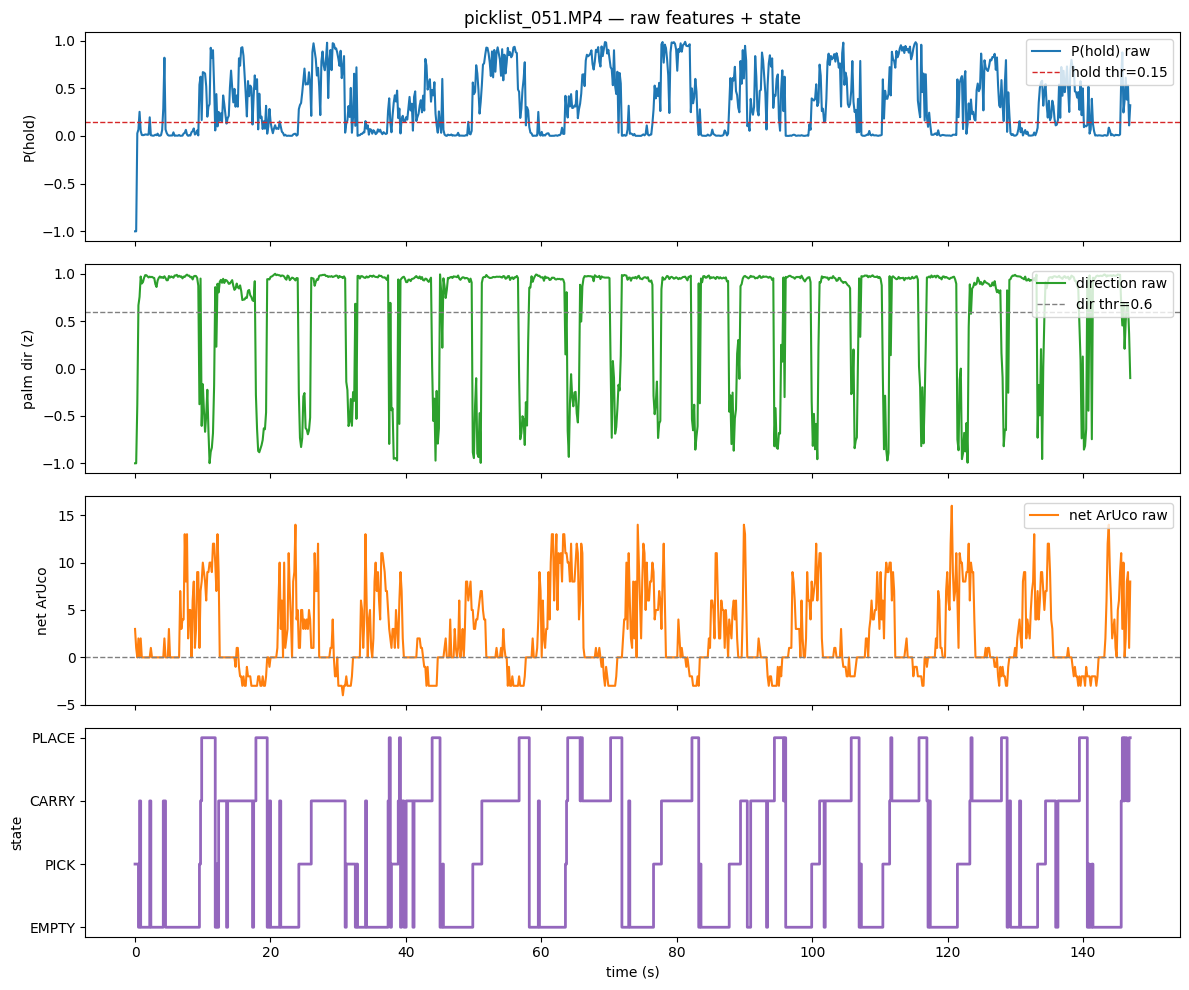

-> csv_outputs/picklist_051_holding_timeseries_smoothed.csv
-> csv_outputs/picklist_051_hand_direction_smoothed.csv
-> csv_outputs/picklist_051_aruco_net_timeseries_smoothed.csv
csv_outputs/picklist_051_holding_timeseries_smoothed.csv + csv_outputs/picklist_051_hand_direction_smoothed.csv -> csv_outputs/picklist_051_state_timeseries_smoothed.csv  (882 rows)


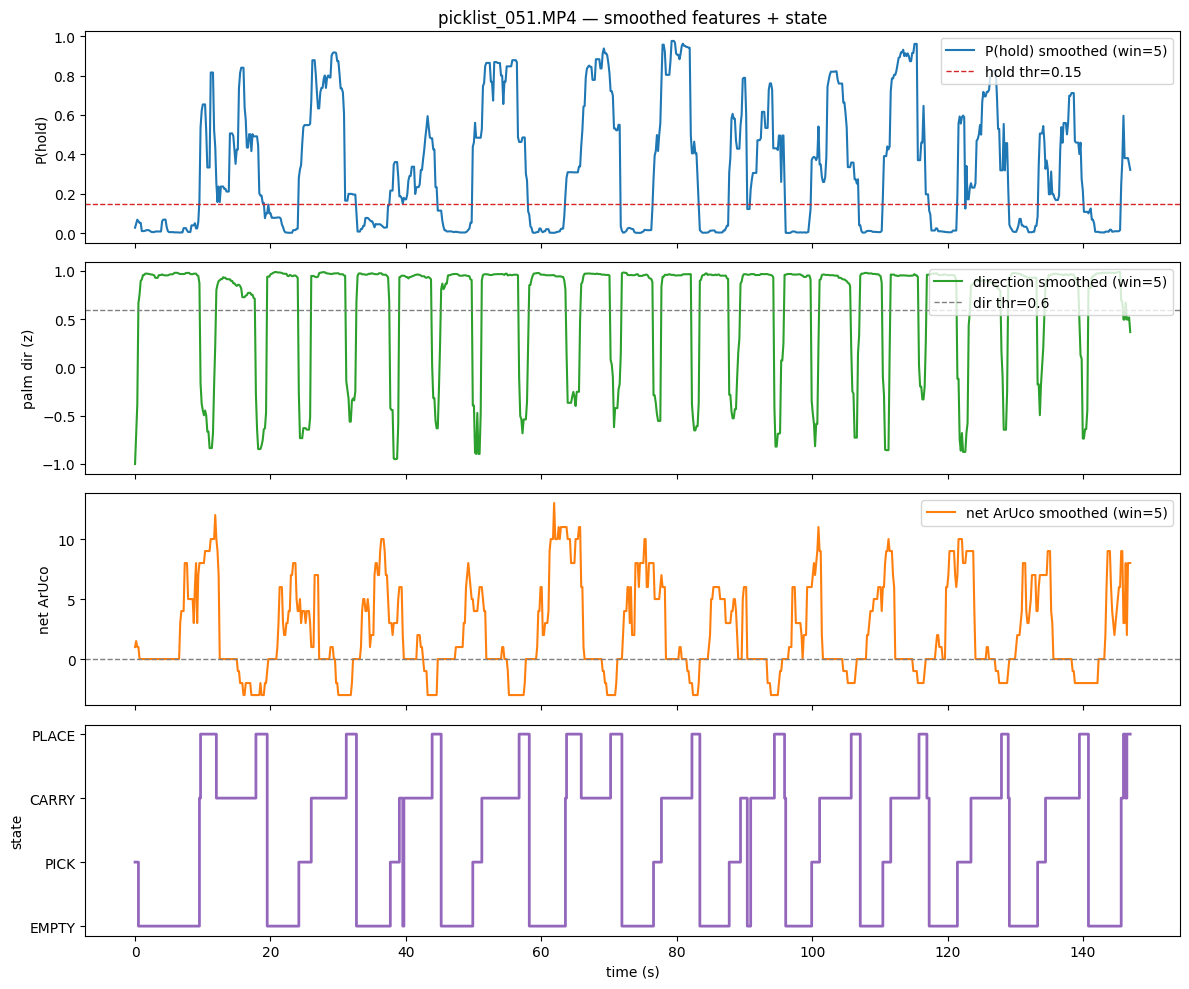

In [17]:
# --- timeseries visualization + median smoothing ---
import matplotlib.pyplot as plt

STATE_LEVELS = {"EMPTY": 0, "PICK": 1, "CARRY": 2, "PLACE": 3}

def load_feature_csv(csv_path):
    times, frame_idxs, values = [], [], []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            times.append(float(row[0]))
            frame_idxs.append(int(row[1]))
            values.append(float(row[2]) if row[2] != "" else np.nan)
    return np.array(times), np.array(frame_idxs), np.array(values, dtype=float)

def state_times_and_levels(state_rows):
    times = np.array([r[1] for r in state_rows])
    levels = np.array([STATE_LEVELS[r[4]] for r in state_rows])
    return times, levels

def median_smooth_1d(values, window):
    if window <= 1:
        return values.copy()
    half = window // 2
    out = np.empty(len(values), dtype=float)
    for k in range(len(values)):
        chunk = values[max(0, k - half): k + half + 1]
        out[k] = np.nanmedian(chunk)
    return out

def write_smoothed_csv(path, times, frame_idxs, values, value_col, fmt):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", value_col])
        for t, fi, v in zip(times, frame_idxs, values):
            if np.isnan(v):
                w.writerow([f"{t:.3f}", fi, ""])
            else:
                w.writerow([f"{t:.3f}", fi, format(v, fmt)])

def plot_features_and_state(times, hold, direction, aruco, state_times, state_levels,
                            hold_label, dir_label, aruco_label, title):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(times, hold, color="tab:blue", linewidth=1.5, label=hold_label)
    axes[0].axhline(HOLD_THRESHOLD, color="tab:red", linestyle="--", linewidth=1,
                    label=f"hold thr={HOLD_THRESHOLD}")
    axes[0].set_ylabel("P(hold)")
    axes[0].legend(loc="upper right")

    axes[1].plot(times, direction, color="tab:green", linewidth=1.5, label=dir_label)
    axes[1].axhline(DIRECTION_THRESHOLD, color="gray", linestyle="--", linewidth=1,
                    label=f"dir thr={DIRECTION_THRESHOLD}")
    axes[1].set_ylabel("palm dir (z)")
    axes[1].legend(loc="upper right")

    axes[2].plot(times, aruco, color="tab:orange", linewidth=1.5, label=aruco_label)
    axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[2].set_ylabel("net ArUco")
    axes[2].legend(loc="upper right")

    axes[3].step(state_times, state_levels, where="post", color="tab:purple", linewidth=2)
    axes[3].set_yticks(list(STATE_LEVELS.values()))
    axes[3].set_yticklabels(list(STATE_LEVELS.keys()))
    axes[3].set_ylabel("state")
    axes[3].set_xlabel("time (s)")

    axes[0].set_title(title)
    plt.tight_layout()
    plt.show()

# load raw series
t_hold, fi_hold, hold_raw = load_feature_csv(OUTPUT_CSV)
t_dir, fi_dir, dir_raw = load_feature_csv(DIRECTION_CSV)
t_aruco, fi_aruco, aruco_raw = load_feature_csv(ARUCO_CSV)
if len(t_hold) != len(t_dir) or not np.all(fi_hold == fi_dir):
    raise ValueError("Holding and direction CSVs are not aligned on frame_idx")
if len(t_hold) != len(t_aruco) or not np.all(fi_hold == fi_aruco):
    raise ValueError("Holding and ArUco CSVs are not aligned on frame_idx")

times = t_hold
frame_idxs = fi_hold
raw_state_times, raw_state_levels = state_times_and_levels(raw_state_rows)

plot_features_and_state(
    times, hold_raw, dir_raw, aruco_raw, raw_state_times, raw_state_levels,
    hold_label="P(hold) raw", dir_label="direction raw", aruco_label="net ArUco raw",
    title=f"{VIDEO_PATH.name} — raw features + state",
)

# smooth and export
hold_for_smooth = np.where(hold_raw < 0, np.nan, hold_raw)
hold_sm = median_smooth_1d(hold_for_smooth, PLOT_SMOOTH_WIN)
dir_sm = median_smooth_1d(dir_raw, PLOT_SMOOTH_WIN)
aruco_sm = median_smooth_1d(aruco_raw, PLOT_SMOOTH_WIN)

write_smoothed_csv(HOLDING_SMOOTHED_CSV, times, frame_idxs, hold_sm, "p_hold_smoothed", ".4f")
write_smoothed_csv(DIRECTION_SMOOTHED_CSV, times, frame_idxs, dir_sm, "direction_smoothed", ".5f")
write_smoothed_csv(ARUCO_SMOOTHED_CSV, times, frame_idxs, aruco_sm, "net_aruco_smoothed", ".5f")
print(f"-> {HOLDING_SMOOTHED_CSV}")
print(f"-> {DIRECTION_SMOOTHED_CSV}")
print(f"-> {ARUCO_SMOOTHED_CSV}")

# Single-video HTK export: p_hold, direction, net_aruco at full frame rate
cap_htk = cv2.VideoCapture(str(VIDEO_PATH))
total_frames = int(cap_htk.get(cv2.CAP_PROP_FRAME_COUNT)) if cap_htk.isOpened() else 0
cap_htk.release()
if total_frames <= 0:
    total_frames = int(frame_idxs[-1]) + FRAME_STRIDE if len(frame_idxs) else 0
expanded = []
for h, d, a in zip(hold_sm, dir_sm, aruco_sm):
    hh = 0.0 if (h is None or np.isnan(h)) else float(h)
    dd = 0.0 if (d is None or np.isnan(d)) else float(d)
    aa = 0.0 if (a is None or np.isnan(a)) else float(a)
    expanded.extend([(hh, dd, aa)] * FRAME_STRIDE)
expanded = expanded[:total_frames]
htk_path = HTK_FEATURES_DIR / VIDEO_PATH.stem
with open(htk_path, "w") as f:
    for h, d, a in expanded:
        f.write(f"{h:.6e} {d:.6e} {a:.6e}\n")
print(f"HTK  {VIDEO_PATH.stem}: {len(hold_sm)} sampled -> {len(expanded)} frames -> {htk_path}")

smoothed_state_rows = build_state_timeseries(
    HOLDING_SMOOTHED_CSV, DIRECTION_SMOOTHED_CSV, STATE_SMOOTHED_CSV,
)
sm_state_times, sm_state_levels = state_times_and_levels(smoothed_state_rows)

plot_features_and_state(
    times, hold_sm, dir_sm, aruco_sm, sm_state_times, sm_state_levels,
    hold_label=f"P(hold) smoothed (win={PLOT_SMOOTH_WIN})",
    dir_label=f"direction smoothed (win={PLOT_SMOOTH_WIN})",
    aruco_label=f"net ArUco smoothed (win={PLOT_SMOOTH_WIN})",
    title=f"{VIDEO_PATH.name} — smoothed features + state",
)


In [18]:
# --- combined annotated video (reads STATE_SMOOTHED_CSV + ARUCO_SMOOTHED_CSV) ---

def load_state_csv(csv_path):
    """Returns list of (frame_idx, time, p_hold, direction, state)."""
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # header
        for row in reader:
            rows.append((int(row[0]), float(row[1]), float(row[2]), float(row[3]), row[4]))
    return rows


def load_overlay_feature_csv(csv_path):
    """Returns list of (frame_idx, time, value) for row_for_frame()."""
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            value = float(row[2]) if row[2] != "" else np.nan
            rows.append((int(row[1]), float(row[0]), value))
    return rows


def row_for_frame(frame_idx, rows):
    """Most recent scored row at or before this video frame."""
    if not rows:
        return None
    chosen = rows[0]
    for row in rows:
        if row[0] <= frame_idx:
            chosen = row
        else:
            break
    return chosen


def draw_stacked_overlay(frame_bgr, lines, margin=16):
    """Stack multiple text lines in a single black box, lower-right."""
    h, w = frame_bgr.shape[:2]
    font      = cv2.FONT_HERSHEY_SIMPLEX
    scale     = max(0.9, min(w, h) / 900.0)
    thickness = max(2, int(round(scale * 2)))
    pad       = 10
    line_gap  = 6

    sizes = [cv2.getTextSize(ln, font, scale, thickness) for ln in lines]
    box_w = max(tw for (tw, _), _ in sizes) + 2 * pad
    box_h = sum(th + baseline for (_, th), baseline in sizes) + line_gap * (len(lines) - 1) + 2 * pad

    x2, y2 = w - margin, h - margin
    x1, y1 = x2 - box_w, y2 - box_h
    cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (0, 0, 0), -1)

    cursor_y = y1 + pad
    for ln, ((tw, th), baseline) in zip(lines, sizes):
        cursor_y += th
        cv2.putText(frame_bgr, ln, (x1 + pad, cursor_y),
                    font, scale, (255, 255, 255), thickness, cv2.LINE_AA)
        cursor_y += baseline + line_gap


def draw_aruco_marker_overlays(frame_bgr, detections):
    """Draw sampled-frame ArUco marker polygons and IDs."""
    for det in detections:
        mid = det["id"]
        color = (0, 255, 0) if mid in PICK_MARKER_IDS else (0, 0, 255)
        pts = det["corners"].astype(np.int32).reshape((-1, 1, 2))
        cv2.polylines(frame_bgr, [pts], True, color, 2)
        cx, cy = det["center"]
        cv2.putText(frame_bgr, str(mid), (int(cx), int(cy)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)


state_rows = load_state_csv(STATE_SMOOTHED_CSV)
aruco_rows = load_overlay_feature_csv(ARUCO_SMOOTHED_CSV)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(VIDEO_PATH)

fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
fw     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fh     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(COMBINED_VIDEO, fourcc, fps, (fw, fh))
if not writer.isOpened():
    cap.release()
    raise RuntimeError(f"Could not open writer for {COMBINED_VIDEO}")

frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    row = row_for_frame(frame_idx, state_rows)
    aruco_row = row_for_frame(frame_idx, aruco_rows)
    if row is None:
        lines = ["P(hold): --", "Dir: --", "ArUco: --", "State: --"]
    else:
        _, _, p_hold, direction, state = row
        if p_hold < 0:
            hold_line = "P(hold): no hand"
        else:
            hold_line = f"P(hold): {p_hold:.4f}"
        aruco_line = "ArUco:  --" if aruco_row is None else f"ArUco:  {aruco_row[2]:+.2f}"
        lines = [hold_line, f"Dir:    {direction:+.3f}", aruco_line, f"State:  {state}"]

    if "frame_aruco_detections" in globals() and frame_idx in frame_aruco_detections:
        draw_aruco_marker_overlays(frame, frame_aruco_detections[frame_idx])

    draw_stacked_overlay(frame, lines)
    writer.write(frame)
    frame_idx += 1

cap.release()
writer.release()
print(
    f"{VIDEO_PATH} + {STATE_SMOOTHED_CSV} + {ARUCO_SMOOTHED_CSV} -> {COMBINED_VIDEO}  "
    f"({frame_idx} frames, FRAME_STRIDE={FRAME_STRIDE})"
)

../hmm-testing/picklist_videos/picklist_051.MP4 + csv_outputs/picklist_051_state_timeseries_smoothed.csv + csv_outputs/picklist_051_aruco_net_timeseries_smoothed.csv -> picklist_051_combined_annotated.mp4  (4406 frames, FRAME_STRIDE=5)


In [20]:
# --- BATCH: inference + state + smoothing for multiple videos ---
# Prerequisite: run cells 1-2 (config + model) in this kernel session.
# Does NOT render videos or plots.

BATCH_VIDEO_DIR = Path("../hmm-testing/picklist_videos")
BATCH_OUTPUT_DIR = CSV_OUTPUT_DIR   # same csv_outputs/ folder as single-video pipeline
BATCH_VIDEO_NAMES = [
    "picklist_112.MP4",
    "picklist_113.MP4",
    "picklist_114.MP4",
    "picklist_115.MP4",
    "picklist_122.MP4",
    "picklist_123.MP4",
    "picklist_124.MP4",
    "picklist_125.MP4",
    "picklist_132.MP4",
    "picklist_133.MP4",
    "picklist_134.MP4",
    "picklist_135.MP4",
    "picklist_142.MP4",
    "picklist_143.MP4",
    "picklist_144.MP4",
    "picklist_145.MP4",
    "picklist_152.MP4",
    "picklist_153.MP4",
    "picklist_154.MP4",
    "picklist_155.MP4",
    "picklist_162.MP4",
    "picklist_163.MP4",
    "picklist_164.MP4",
    "picklist_165.MP4",
    "picklist_172.MP4",
    "picklist_173.MP4",
    "picklist_174.MP4",
    "picklist_175.MP4",
    "picklist_182.MP4",
    "picklist_183.MP4",
    "picklist_184.MP4",
    "picklist_185.MP4",
    "picklist_192.MP4",
    "picklist_193.MP4",
    "picklist_194.MP4",
    "picklist_195.MP4",
    "picklist_202.MP4",
    "picklist_203.MP4",
    "picklist_204.MP4",
    "picklist_205.MP4",
    "picklist_212.MP4",
    "picklist_213.MP4",
    "picklist_214.MP4",
    "picklist_215.MP4",
    "picklist_222.MP4",
    "picklist_223.MP4",
    "picklist_224.MP4",
    "picklist_225.MP4",
    "picklist_232.MP4",
    "picklist_233.MP4",
    "picklist_234.MP4",
    "picklist_235.MP4",
    "picklist_242.MP4",
    "picklist_243.MP4",
    "picklist_244.MP4",
    "picklist_245.MP4",
    "picklist_252.MP4",
    "picklist_253.MP4",
    "picklist_254.MP4",
    "picklist_255.MP4",
    "picklist_262.MP4",
    "picklist_263.MP4",
    "picklist_264.MP4",
    "picklist_265.MP4",
    "picklist_272.MP4",
    "picklist_273.MP4",
    "picklist_274.MP4",
    "picklist_275.MP4",
    "picklist_282.MP4",
    "picklist_283.MP4",
    "picklist_284.MP4",
    "picklist_285.MP4",
    "picklist_292.MP4",
    "picklist_293.MP4",
    "picklist_294.MP4",
    "picklist_295.MP4",
    "picklist_302.MP4",
    "picklist_303.MP4",
    "picklist_304.MP4",
    "picklist_305.MP4",
    "picklist_312.MP4",
    "picklist_313.MP4",
    "picklist_314.MP4",
    "picklist_315.MP4",
    "picklist_322.MP4",
    "picklist_323.MP4",
    "picklist_324.MP4",
    "picklist_325.MP4",
    "picklist_332.MP4",
    "picklist_333.MP4",
    "picklist_334.MP4",
    "picklist_335.MP4",
    "picklist_342.MP4",
    "picklist_343.MP4",
    "picklist_344.MP4",
    "picklist_345.MP4",
    "picklist_352.MP4",
    "picklist_353.MP4",
    "picklist_354.MP4",
    "picklist_355.MP4",
    "picklist_362.MP4",
    "picklist_363.MP4",
    "picklist_364.MP4",
    "picklist_365.MP4",
    "picklist_372.MP4",
    "picklist_373.MP4",
    "picklist_374.MP4",
    "picklist_375.MP4",
    "picklist_382.MP4",
    "picklist_383.MP4",
    "picklist_384.MP4",
    "picklist_385.MP4",
    "picklist_392.MP4",
    "picklist_393.MP4",
    "picklist_394.MP4",
    "picklist_395.MP4",
    "picklist_402.MP4",
    "picklist_403.MP4",
    "picklist_404.MP4",
    "picklist_405.MP4",
    "picklist_412.MP4",
    "picklist_413.MP4",
    "picklist_414.MP4",
    "picklist_415.MP4",
    "picklist_422.MP4",
    "picklist_423.MP4",
    "picklist_424.MP4",
    "picklist_425.MP4",
    "picklist_432.MP4",
    "picklist_433.MP4",
    "picklist_434.MP4",
    "picklist_435.MP4",
    "picklist_442.MP4",
    "picklist_443.MP4",
    "picklist_444.MP4",
    "picklist_445.MP4",
    "picklist_452.MP4",
    "picklist_453.MP4",
    "picklist_454.MP4",
    "picklist_455.MP4",
    "picklist_462.MP4",
    "picklist_463.MP4",
    "picklist_464.MP4",
    "picklist_465.MP4",
    "picklist_472.MP4",
    "picklist_473.MP4",
    "picklist_474.MP4",
    "picklist_475.MP4",
    "picklist_482.MP4",
    "picklist_483.MP4",
    "picklist_484.MP4",
    "picklist_485.MP4",
    "picklist_492.MP4",
    "picklist_493.MP4",
    "picklist_494.MP4",
    "picklist_495.MP4",
    "picklist_502.MP4",
    "picklist_503.MP4",
    "picklist_504.MP4",
    "picklist_505.MP4"
]

if "analyze_frame" not in globals():
    raise RuntimeError("Run cells 1-2 (config + model setup) before this batch cell.")


def batch_csv_paths(stem, out_dir=BATCH_OUTPUT_DIR):
    out_dir = Path(out_dir)
    return {
        "holding": out_dir / f"{stem}_holding_timeseries.csv",
        "direction": out_dir / f"{stem}_hand_direction.csv",
        "aruco": out_dir / f"{stem}_aruco_net_timeseries.csv",
        "state": out_dir / f"{stem}_state_timeseries.csv",
        "holding_sm": out_dir / f"{stem}_holding_timeseries_smoothed.csv",
        "direction_sm": out_dir / f"{stem}_hand_direction_smoothed.csv",
        "aruco_sm": out_dir / f"{stem}_aruco_net_timeseries_smoothed.csv",
        "state_sm": out_dir / f"{stem}_state_timeseries_smoothed.csv",
    }


def batch_run_on_video(video_path, holding_csv, direction_csv, aruco_csv):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    times, frame_indices = [], []
    hold_probs, dir_vals, aruco_vals = [], [], []
    aruco_pick_counts, aruco_place_counts, aruco_id_strs = [], [], []

    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % FRAME_STRIDE == 0:
            p, z = analyze_frame(frame)
            net_aruco, pick_count, place_count, unique_ids, _ = analyze_aruco_frame(frame)

            hold_probs.append(p)
            dir_vals.append(z)
            aruco_vals.append(net_aruco)
            aruco_pick_counts.append(pick_count)
            aruco_place_counts.append(place_count)
            aruco_id_strs.append(";".join(str(i) for i in unique_ids))
            times.append(frame_idx / fps)
            frame_indices.append(frame_idx)
        frame_idx += 1
    cap.release()

    arr = np.array(hold_probs, dtype=float)
    half = SMOOTH_WIN // 2
    sm = np.array([np.median(arr[max(0, k - half): k + half + 1]) for k in range(len(arr))])

    with open(holding_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "p_hold"])
        for t, fi, pv in zip(times, frame_indices, sm):
            w.writerow([f"{t:.3f}", fi, f"{pv:.4f}"])

    with open(direction_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "direction"])
        for t, fi, z in zip(times, frame_indices, dir_vals):
            w.writerow([f"{t:.3f}", fi, f"{z:.5f}"])

    with open(aruco_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", "net_aruco", "pick_count", "place_count", "detected_ids"])
        for t, fi, net_v, pc, plc, ids_s in zip(
            times, frame_indices, aruco_vals, aruco_pick_counts, aruco_place_counts, aruco_id_strs
        ):
            w.writerow([f"{t:.3f}", fi, net_v, pc, plc, ids_s])

    return len(times)


def batch_load_timeseries_csv(csv_path):
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            val = float(row[2]) if row[2] != "" else 0.0
            rows.append((float(row[0]), int(row[1]), val))
    return rows


def batch_infer_state(hold_prob, direction, prev_state):
    if direction > DIRECTION_THRESHOLD:
        if hold_prob > HOLD_THRESHOLD:
            return "CARRY"
        if hold_prob < HOLD_THRESHOLD:
            return "EMPTY"
        return prev_state
    if direction <= DIRECTION_THRESHOLD:
        if prev_state == "EMPTY":
            return "PICK"
        if prev_state == "CARRY":
            return "PLACE"
        return prev_state
    return prev_state


def batch_build_state_timeseries(holding_csv, direction_csv, state_csv):
    hold_rows = batch_load_timeseries_csv(holding_csv)
    dir_rows = batch_load_timeseries_csv(direction_csv)
    if len(hold_rows) != len(dir_rows):
        raise ValueError(f"Row count mismatch: {len(hold_rows)} vs {len(dir_rows)}")

    states = []
    prev = "EMPTY"
    for (t_h, fi_h, hold_prob), (t_d, fi_d, direction) in zip(hold_rows, dir_rows):
        if fi_h != fi_d or abs(t_h - t_d) > 1e-3:
            raise ValueError(f"Alignment mismatch at frame {fi_h}")
        hold_for_state = 0.0 if hold_prob < 0 else hold_prob
        state = batch_infer_state(hold_for_state, direction, prev)
        states.append((fi_h, t_h, hold_prob, direction, state))
        prev = state

    with open(state_csv, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["frame_idx", "time_s", "p_hold", "direction", "state"])
        for fi, t, hold_prob, direction, state in states:
            w.writerow([fi, f"{t:.3f}", f"{hold_prob:.4f}", f"{direction:.5f}", state])
    return len(states)


def batch_load_feature_csv(csv_path):
    times, frame_idxs, values = [], [], []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            times.append(float(row[0]))
            frame_idxs.append(int(row[1]))
            values.append(float(row[2]) if row[2] != "" else np.nan)
    return np.array(times), np.array(frame_idxs), np.array(values, dtype=float)


def batch_median_smooth_1d(values, window):
    if window <= 1:
        return values.copy()
    half = window // 2
    out = np.empty(len(values), dtype=float)
    for k in range(len(values)):
        chunk = values[max(0, k - half): k + half + 1]
        out[k] = np.nanmedian(chunk)
    return out


def batch_write_smoothed_csv(path, times, frame_idxs, values, value_col, fmt):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["time_s", "frame_idx", value_col])
        for t, fi, v in zip(times, frame_idxs, values):
            if np.isnan(v):
                w.writerow([f"{t:.3f}", fi, ""])
            else:
                w.writerow([f"{t:.3f}", fi, format(v, fmt)])


def batch_smooth_timeseries(holding_csv, direction_csv, aruco_csv, holding_sm_csv, direction_sm_csv, aruco_sm_csv):
    times, frame_idxs, hold_raw = batch_load_feature_csv(holding_csv)
    t_dir, fi_dir, dir_raw = batch_load_feature_csv(direction_csv)
    t_aruco, fi_aruco, aruco_raw = batch_load_feature_csv(aruco_csv)
    if len(times) != len(t_dir) or not np.all(frame_idxs == fi_dir):
        raise ValueError("Holding and direction CSVs are not aligned")
    if len(times) != len(t_aruco) or not np.all(frame_idxs == fi_aruco):
        raise ValueError("Holding and ArUco CSVs are not aligned")

    hold_sm = batch_median_smooth_1d(np.where(hold_raw < 0, np.nan, hold_raw), PLOT_SMOOTH_WIN)
    dir_sm = batch_median_smooth_1d(dir_raw, PLOT_SMOOTH_WIN)
    aruco_sm = batch_median_smooth_1d(aruco_raw, PLOT_SMOOTH_WIN)
    batch_write_smoothed_csv(holding_sm_csv, times, frame_idxs, hold_sm, "p_hold_smoothed", ".4f")
    batch_write_smoothed_csv(direction_sm_csv, times, frame_idxs, dir_sm, "direction_smoothed", ".5f")
    batch_write_smoothed_csv(aruco_sm_csv, times, frame_idxs, aruco_sm, "net_aruco_smoothed", ".5f")


def batch_process_video(video_path, output_dir=BATCH_OUTPUT_DIR):
    video_path = Path(video_path)
    if not video_path.is_file():
        raise FileNotFoundError(video_path)

    paths = batch_csv_paths(video_path.stem, output_dir)
    n = batch_run_on_video(video_path, paths["holding"], paths["direction"], paths["aruco"])
    batch_build_state_timeseries(paths["holding"], paths["direction"], paths["state"])
    batch_smooth_timeseries(
        paths["holding"], paths["direction"], paths["aruco"],
        paths["holding_sm"], paths["direction_sm"], paths["aruco_sm"],
    )
    batch_build_state_timeseries(paths["holding_sm"], paths["direction_sm"], paths["state_sm"])
    return {"video": str(video_path), "rows": n, **{k: str(v) for k, v in paths.items()}}


batch_results = []
batch_errors = []
for name in BATCH_VIDEO_NAMES:
    video_path = BATCH_VIDEO_DIR / name
    print(f"\n=== {name} ===")
    try:
        result = batch_process_video(video_path)
        batch_results.append(result)
        print(f"OK  rows={result['rows']}")
        print(f"    {result['state_sm']}")
    except Exception as exc:
        batch_errors.append((name, exc))
        print(f"FAIL  {exc}")

print(f"\nBatch complete: {len(batch_results)} succeeded, {len(batch_errors)} failed")
if batch_errors:
    for name, exc in batch_errors:
        print(f"  - {name}: {exc}")

# --- HTK: export 3-dim feature files from smoothed CSVs ---
HTK_FEATURES_DIR = Path("../hmm-testing/processed_features_3d")
HTK_FEATURES_DIR.mkdir(parents=True, exist_ok=True)


def _load_smoothed_value_column(csv_path):
    vals = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        next(reader, None)
        for row in reader:
            if row[2] == "":
                vals.append(0.0)
            else:
                v = float(row[2])
                vals.append(0.0 if np.isnan(v) else v)
    return vals


def batch_load_smoothed_htk_features(holding_sm_csv, direction_sm_csv, aruco_sm_csv):
    hold_vals = _load_smoothed_value_column(holding_sm_csv)
    dir_vals = _load_smoothed_value_column(direction_sm_csv)
    aruco_vals = _load_smoothed_value_column(aruco_sm_csv)
    if len(hold_vals) != len(dir_vals) or len(hold_vals) != len(aruco_vals):
        raise ValueError(
            f"Smoothed row mismatch: hold={len(hold_vals)} dir={len(dir_vals)} aruco={len(aruco_vals)}"
        )
    return hold_vals, dir_vals, aruco_vals


def batch_video_frame_count(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return total


def batch_expand_features_to_full_rate(hold_vals, dir_vals, aruco_vals, total_frames, stride=FRAME_STRIDE):
    expanded = []
    for h, d, a in zip(hold_vals, dir_vals, aruco_vals):
        expanded.extend([(h, d, a)] * stride)
    return expanded[:total_frames]


def batch_write_htk_features(out_path, frames):
    with open(out_path, "w") as f:
        for h, d, a in frames:
            f.write(f"{h:.6e} {d:.6e} {a:.6e}\n")


htk_exports = []
for result in batch_results:
    video_path = Path(result["video"])
    stem = video_path.stem
    hold_vals, dir_vals, aruco_vals = batch_load_smoothed_htk_features(
        result["holding_sm"], result["direction_sm"], result["aruco_sm"]
    )
    total_frames = batch_video_frame_count(video_path)
    frames = batch_expand_features_to_full_rate(hold_vals, dir_vals, aruco_vals, total_frames)
    out_path = HTK_FEATURES_DIR / stem
    batch_write_htk_features(out_path, frames)
    htk_exports.append({
        "video": stem,
        "sampled_rows": len(hold_vals),
        "htk_frames": len(frames),
        "total_frames": total_frames,
        "path": str(out_path),
    })
    print(f"HTK  {stem}: {len(hold_vals)} sampled -> {len(frames)} frames -> {out_path}")

print(f"\nHTK export complete: {len(htk_exports)} feature file(s) in {HTK_FEATURES_DIR}")



=== picklist_112.MP4 ===


/var/folders/5p/xzjmrhjj1nz7l64wg84psm0w0000gn/T/ipykernel_4458/523965836.py:315: RuntimeWarning: All-NaN slice encountered
  out[k] = np.nanmedian(chunk)


OK  rows=507
    csv_outputs/picklist_112_state_timeseries_smoothed.csv

=== picklist_113.MP4 ===
OK  rows=690
    csv_outputs/picklist_113_state_timeseries_smoothed.csv

=== picklist_114.MP4 ===
OK  rows=805
    csv_outputs/picklist_114_state_timeseries_smoothed.csv

=== picklist_115.MP4 ===
OK  rows=393
    csv_outputs/picklist_115_state_timeseries_smoothed.csv

=== picklist_122.MP4 ===
OK  rows=404
    csv_outputs/picklist_122_state_timeseries_smoothed.csv

=== picklist_123.MP4 ===
OK  rows=871
    csv_outputs/picklist_123_state_timeseries_smoothed.csv

=== picklist_124.MP4 ===
OK  rows=698
    csv_outputs/picklist_124_state_timeseries_smoothed.csv

=== picklist_125.MP4 ===
OK  rows=490
    csv_outputs/picklist_125_state_timeseries_smoothed.csv

=== picklist_132.MP4 ===
OK  rows=440
    csv_outputs/picklist_132_state_timeseries_smoothed.csv

=== picklist_133.MP4 ===
OK  rows=722
    csv_outputs/picklist_133_state_timeseries_smoothed.csv

=== picklist_134.MP4 ===
OK  rows=677
    csv